# 📊 EDA — SRDB Studies Dataset (V5)

**File:** `srdb-studies-V5.csv`  
**Rows:** 11,701 | **Columns:** 18  
**Description:** Bibliographic metadata for studies in the SRDB. Contains authors, titles, journals, DOIs, publication years, and search metadata.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [2]:
from pathlib import Path
raw = Path('../data/raw')
df = pd.read_csv(raw / 'srdb-studies-V5.csv', encoding='latin1')
print(f"Shape: {df.shape}")
df.head()


Shape: (11701, 18)


,Study_number,Authors,Title,Source,Volume,Issue,BP,EP,PubYear,Notes,Citations,DE,DLD,DOI,nonEnglish,Rank,SearchDate,SearchTerm
0,1,"HARLEY, JL; BRIERLEY, JK",A METHOD OF ESTIMATION OF OXYGEN AND CARBON DI...,JOURNAL OF ECOLOGY,41,2,385,387,1953.0,NaN,2,NaN,NaN,NaN,N,3.0,9/26/2008,"Topic=(""soil co2 evolution"" not ""soil respirat..."
1,2,"ZONN, SV; ALESHINA, AK",O GAZOOBMENE MEZHDU POCHVOI I ATMOSFEROI POD P...,DOKLADY AKADEMII NAUK SSSR,92,5,1035,1038,1953.0,NaN,0,NaN,NaN,NaN,N,3.0,9/26/2008,"Topic=(""soil co2 evolution"" not ""soil respirat..."
2,3,"BOLLEN, WB; MORRISON, HE; CROWELL, HH",EFFECT OF FIELD AND LABORATORY TREATMENTS WITH...,JOURNAL OF ECONOMIC ENTOMOLOGY,47,2,307,312,1954.0,NaN,15,NaN,NaN,NaN,N,3.0,9/26/2008,"Topic=(""soil respiration"")"
3,4,"STEVENSON, IL; CHASE, FE",MICROBIOLOGICAL STUDIES ON AN ORCHARD SOIL UND...,CANADIAN JOURNAL OF MICROBIOLOGY,3,2,351,358,1957.0,NaN,5,NaN,NaN,NaN,N,3.0,9/26/2008,"Topic=(""soil respiration"")"
4,5,"MAKAROV, BN",DIURNAL VARIATION OF SOIL RESPIRATION AND CARB...,DOKLADY AKADEMII NAUK SSSR,118,2,389,391,1958.0,NaN,1,N,Y,NaN,N,2.0,9/26/2008,"Topic=(""soil respiration"")"


## 2. Basic Information


In [3]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11701 entries, 0 to 11700
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Study_number  11701 non-null  int64  
 1   Authors       11700 non-null  object 
 2   Title         11699 non-null  object 
 3   Source        11699 non-null  object 
 4   Volume        11478 non-null  object 
 5   Issue         9143 non-null   object 
 6   BP            10868 non-null  object 
 7   EP            10674 non-null  object 
 8   PubYear       11700 non-null  float64
 9   Notes         138 non-null    object 
 10  Citations     6763 non-null   object 
 11  DE            4506 non-null   object 
 12  DLD           4586 non-null   object 
 13  DOI           8093 non-null   object 
 14  nonEnglish    11701 non-null  object 
 15  Rank          11601 non-null  float64
 16  SearchDate    10231 non-null  object 
 17  SearchTerm    8563 non-null   object 
dtypes: float64(2), int64(1), o

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Study_number,11701.0,NaN,NaN,NaN,5919.897274,3440.246127,1.0,2926.0,5947.0,8916.0,12008.0
Authors,11700,11349,"Shi, Andong; Marschner, Petra",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,11699,11605,Aggregated estimation of basic parameters of b...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,11699,1424,SOIL BIOLOGY & BIOCHEMISTRY,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,11478,544,10,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue,9143,226,1,1246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BP,10868,2629,1,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EP,10674,2686,&,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PubYear,11700.0,NaN,NaN,NaN,2007.980256,9.007004,1927.0,2005.0,2011.0,2014.0,2020.0
Notes,138,32,In Chinese with English abstract,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values


Total missing: 43,774
              Count  Percent
Notes         11563    98.82
DE             7195    61.49
DLD            7115    60.81
Citations      4938    42.20
DOI            3608    30.83
SearchTerm     3138    26.82
Issue          2558    21.86
SearchDate     1470    12.56
EP             1027     8.78
BP              833     7.12
Volume          223     1.91
Rank            100     0.85
Source            2     0.02
Title             2     0.02
PubYear           1     0.01
Authors           1     0.01
Study_number      0     0.00
nonEnglish        0     0.00


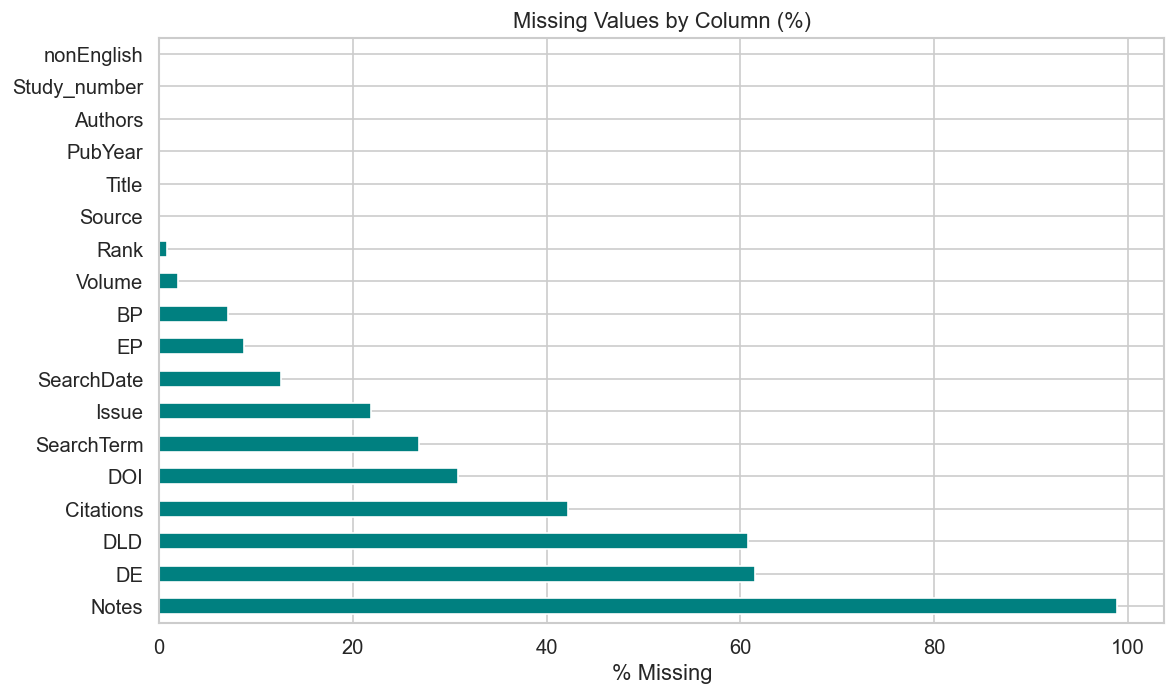

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct}).sort_values('Percent', ascending=False)
print(f"Total missing: {missing.sum():,}")
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Percent'].plot(kind='barh', ax=ax, color='teal')
ax.set_title('Missing Values by Column (%)')
ax.set_xlabel('% Missing')
plt.tight_layout()
plt.show()


## 4. Publication Year Trends


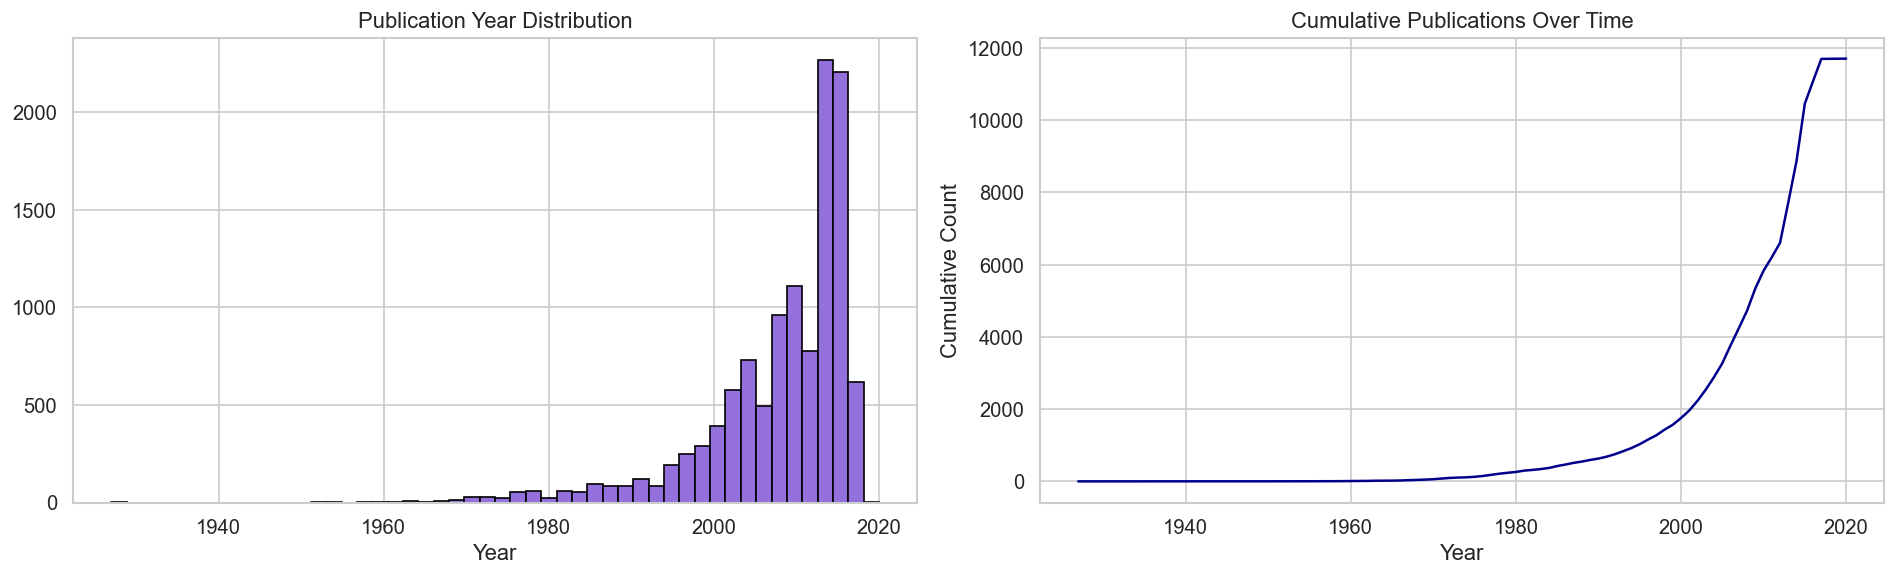

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

years = df['PubYear'].dropna()
years.hist(bins=50, ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('Publication Year Distribution')
axes[0].set_xlabel('Year')

# Cumulative publications
year_counts = years.value_counts().sort_index().cumsum()
year_counts.plot(ax=axes[1], color='darkblue')
axes[1].set_title('Cumulative Publications Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cumulative Count')

plt.tight_layout()
plt.show()


## 5. Top Journals / Sources


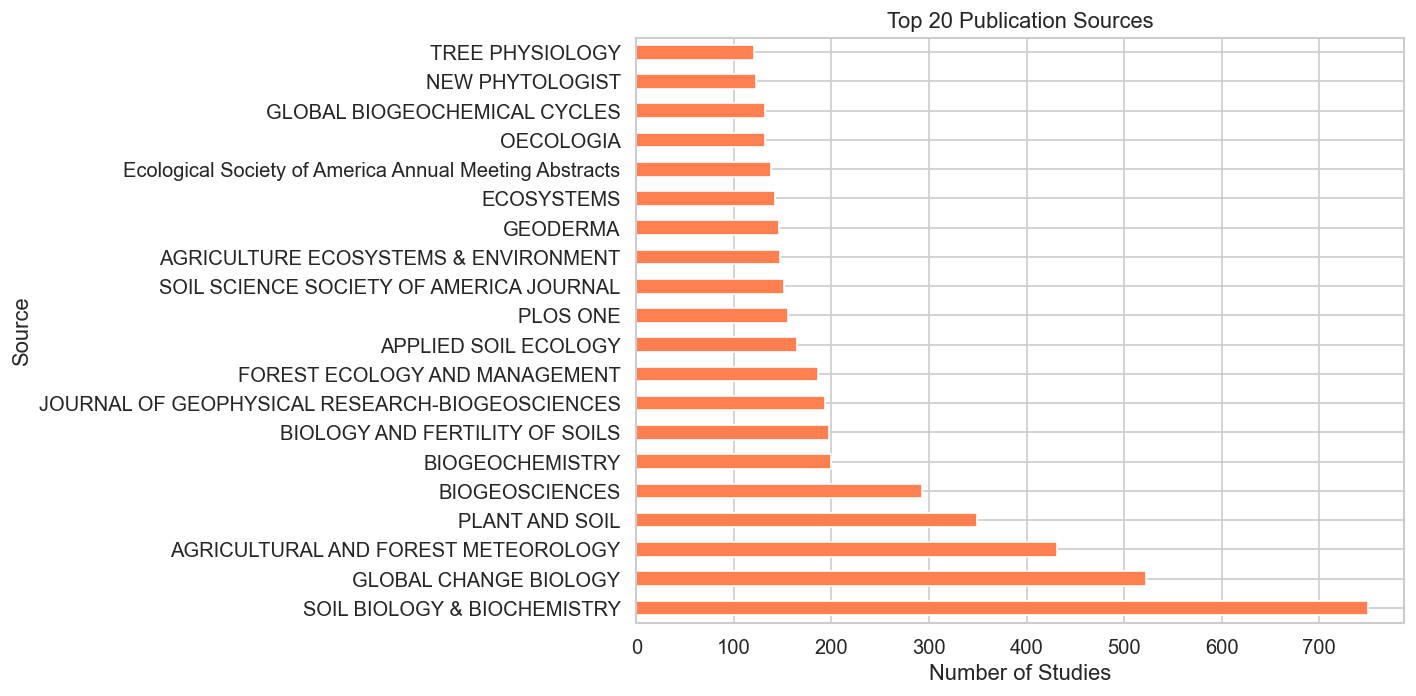

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
top_sources = df['Source'].value_counts().head(20)
top_sources.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 Publication Sources')
ax.set_xlabel('Number of Studies')
plt.tight_layout()
plt.show()


## 6. Language Distribution


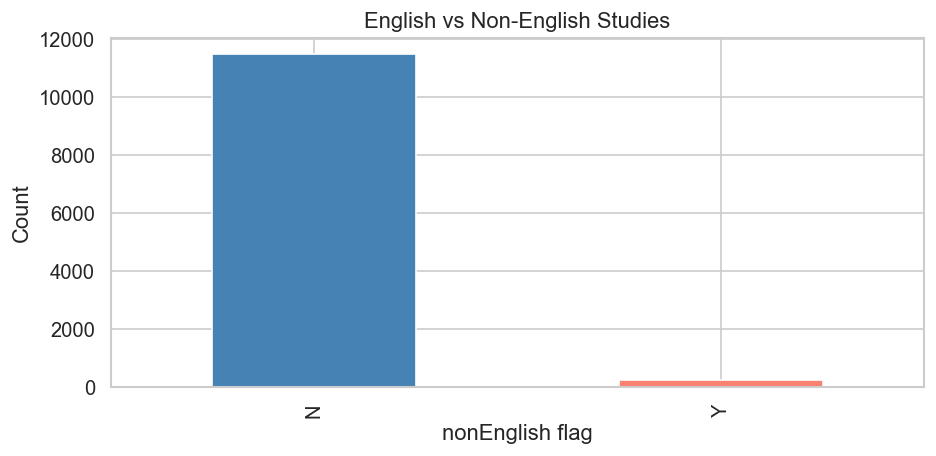

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
lang = df['nonEnglish'].value_counts()
lang.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title('English vs Non-English Studies')
ax.set_xlabel('nonEnglish flag')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 7. DOI Availability


DOI available: 8093 (69.2%)
DOI missing:   3608 (30.8%)


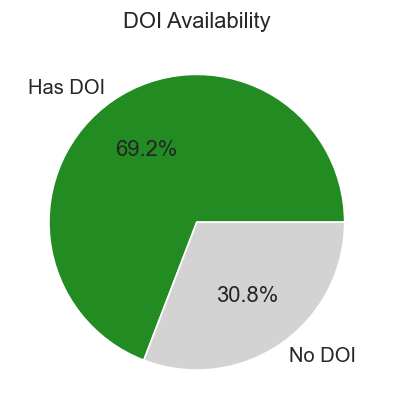

In [9]:
doi_available = df['DOI'].notna().sum()
doi_missing = df['DOI'].isna().sum()
print(f"DOI available: {doi_available} ({doi_available/len(df)*100:.1f}%)")
print(f"DOI missing:   {doi_missing} ({doi_missing/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([doi_available, doi_missing], labels=['Has DOI', 'No DOI'],
       autopct='%1.1f%%', colors=['forestgreen', 'lightgray'])
ax.set_title('DOI Availability')
plt.show()


## 8. Study Ranking Distribution


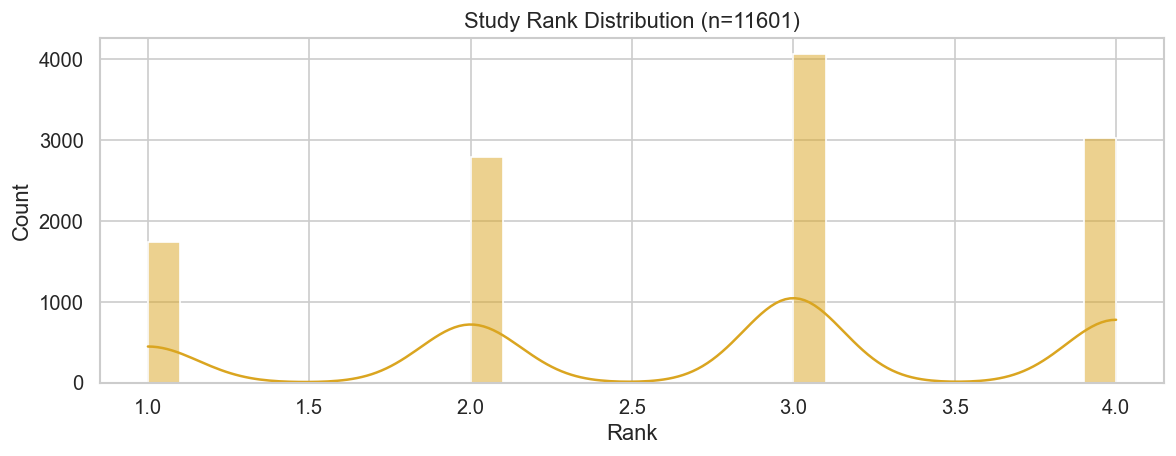

In [10]:
rank = df['Rank'].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(rank, bins=30, ax=ax, color='goldenrod', kde=True)
ax.set_title(f'Study Rank Distribution (n={len(rank)})')
plt.tight_layout()
plt.show()


## 9. Key Findings & Summary

### Dataset Summary
- **11,701 rows × 18 columns** — bibliographic metadata
- Linked to SRDB data via `Study_number`

### Key Observations
1. **Publication growth**: Exponential growth in soil respiration studies, especially post-2000
2. **Top journals**: Dominated by a few key ecology/soil science journals
3. **Language**: Primarily English-language literature with some non-English studies
4. **DOI coverage**: ~69% of studies have DOIs
5. **Missing data**: `Notes` (98.8% missing), `Citations`/`DE`/`DLD` (~40-60% missing)

### Action Plan
- Use `Study_number` to join with SRDB data for integrated analysis
- `PubYear` useful for temporal bias analysis in main dataset
- DOI links enable automated literature review if needed
